IDEAS:

- use a better dataset (no roads / man-made structures)
- use a diverse dataset (rivers, smaller-scale roughness, etc.)
- erode result for realism
- add "traversability loss" (try to guarantee smoothness more)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [4]:
torch.manual_seed(67)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
def gaussian_kernel(size: int, sigma: float):
    ax = torch.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel

def gaussian_blur(img: torch.Tensor, blur_size: int, sigma: float):
    # img shape: (batch, channels, H, W)
    kernel = gaussian_kernel(blur_size, sigma)
    kernel = kernel.expand(img.size(1), 1, blur_size, blur_size)
    return F.conv2d(img, kernel, padding=blur_size//2, groups=img.size(1))

In [7]:
# desired size of the output image
imsize = 512 if torch.cuda.is_available() else 128  # smaller if no GPU

loader = transforms.Compose([
    transforms.Resize(imsize),
    transforms.ToTensor()
])

def image_loader(image_name):
    image = Image.open(image_name)
    image = loader(image).unsqueeze(0)  # add batch dimension
    return image.to(device, torch.float)

# adjust paths to your MyDrive
styles = 10
style_imgs = []
for i in range(1, styles+1):
    style_imgs.append(image_loader(f"/content/drive/MyDrive/Images/style{i}.jpg"))

content_img = image_loader("/content/drive/MyDrive/Images/other.jpg")

for style_img in style_imgs:
  assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

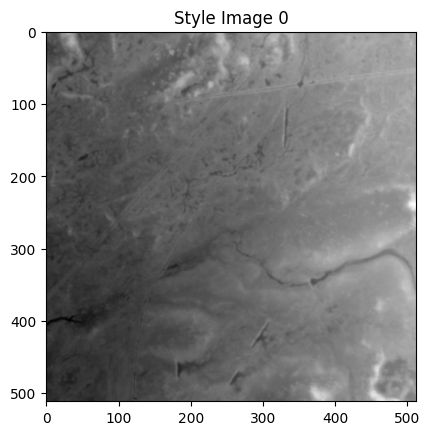

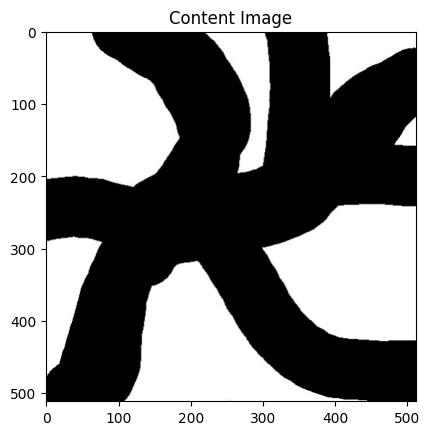

In [8]:
unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated


plt.figure()
imshow(style_imgs[0], title='Style Image 0')

plt.figure()
imshow(content_img, title='Content Image')

In [9]:
class ContentLoss(nn.Module):

    def __init__(self, target, p=2.2):
        super(ContentLoss, self).__init__()
        self.target = target.detach()
        self.p = p

    def forward(self, input):
        diff = input - self.target
        self.loss = torch.mean(torch.abs(diff) ** self.p)
        return input

In [10]:
def gram_matrix(input):
    a, b, c, d = input.size()  # a=batch size(=1)
    # b=number of feature maps
    # (c,d)=dimensions of a f. map (N=c*d)

    features = input.view(a * b, c * d)  # resize F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)

In [11]:
class StyleLoss(nn.Module):
    def __init__(self, target_features):
        super(StyleLoss, self).__init__()
        # target_features is a list of feature tensors (one per style image)
        self.targets = [gram_matrix(t.detach()) for t in target_features]
        self.weights = [1.0 / len(target_features)] * len(target_features)

    def forward(self, input):
        G = gram_matrix(input)
        # min weighted losses over all target style images
        self.loss = min(F.mse_loss(G, target) * w for target, w in zip(self.targets, self.weights))
        return input

In [12]:
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 86.0MB/s]


In [13]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])

# create a module to normalize input image so we can easily put it in a
# ``nn.Sequential``
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize ``img``
        return (img - self.mean) / self.std

In [14]:
# desired depth layers to compute style/content losses :
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_imgs, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std)

    # just in order to have an iterable access to or list of content/style
    # losses
    content_losses = []
    style_losses = []

    # assuming that ``cnn`` is a ``nn.Sequential``, so we make a new ``nn.Sequential``
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            # The in-place version doesn't play very nicely with the ``ContentLoss``
            # and ``StyleLoss`` we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # compute target features for all style images
            target_features = [model(style_img).detach() for style_img in style_imgs]
            # create a single StyleLoss module that averages all targets
            style_loss = StyleLoss(target_features)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses

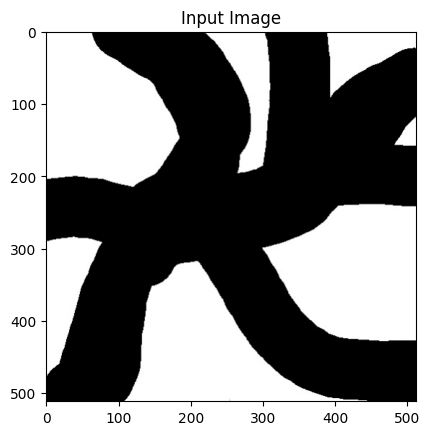

In [15]:
input_img = content_img.clone()
# if you want to use white noise by using the following code:
#
# .. code-block:: python
#
#    input_img = torch.randn(content_img.data.size())

# add the original input image to the figure:
plt.figure()
imshow(input_img, title='Input Image')

In [16]:
print(input_img)

tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], device='cuda:0')


In [17]:
def total_variation_loss(img):
    # img shape: (1,1,H,W) for grayscale or (1,3,H,W) for RGB
    batch_size, channels, height, width = img.size()
    tv_h = torch.pow(img[:, :, 1:, :] - img[:, :, :-1, :], 2).sum()
    tv_w = torch.pow(img[:, :, :, 1:] - img[:, :, :, :-1], 2).sum()
    return (tv_h + tv_w)

In [18]:
def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img])
    return optimizer

In [19]:
def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_imgs, input_img, num_steps=1000,
                       style_weight=1e7, content_weight=2e-1, tv_weight=1.5e-2):
    """Run the style transfer."""
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_imgs, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    # We also put the model in evaluation mode, so that specific layers
    # such as dropout or batch normalization layers behave correctly.
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight
            tv_loss = tv_weight * total_variation_loss(input_img)

            loss = style_score + content_score + tv_loss
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f} TV Loss: {:4f}'.format(
                    style_score.item(), content_score.item(), tv_loss))
                print()

            return style_score + content_score

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    input_img = input_img.mean(dim=1, keepdim=True)

    return input_img

In [20]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_imgs, input_img)  # training loop

Building the style transfer model..


/usr/local/lib/python3.12/dist-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Optimizing..


/usr/local/lib/python3.12/dist-packages/torch/utils/_device.py:103: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return func(*args, **kwargs)


run [50]:
Style Loss : 46.752270 Content Loss: 4.246112 TV Loss: 8.907248

run [100]:
Style Loss : 14.068092 Content Loss: 4.011328 TV Loss: 5.638762

run [150]:
Style Loss : 4.413127 Content Loss: 3.724610 TV Loss: 2.551993

run [200]:
Style Loss : 2.208797 Content Loss: 3.524906 TV Loss: 2.349022

run [250]:
Style Loss : 1.820831 Content Loss: 3.438305 TV Loss: 2.255155

run [300]:
Style Loss : 1.580116 Content Loss: 3.378191 TV Loss: 2.178444

run [350]:
Style Loss : 0.808078 Content Loss: 3.389956 TV Loss: 2.156250

run [400]:
Style Loss : 0.454035 Content Loss: 3.388336 TV Loss: 2.006449

run [450]:
Style Loss : 0.337773 Content Loss: 3.361076 TV Loss: 1.927334

run [500]:
Style Loss : 0.310995 Content Loss: 3.335375 TV Loss: 1.886130

run [550]:
Style Loss : 0.302318 Content Loss: 3.319207 TV Loss: 1.877952

run [600]:
Style Loss : 0.274697 Content Loss: 3.303299 TV Loss: 1.869770

run [650]:
Style Loss : 0.259955 Content Loss: 3.297765 TV Loss: 1.862700

run [700]:
Style Loss : 

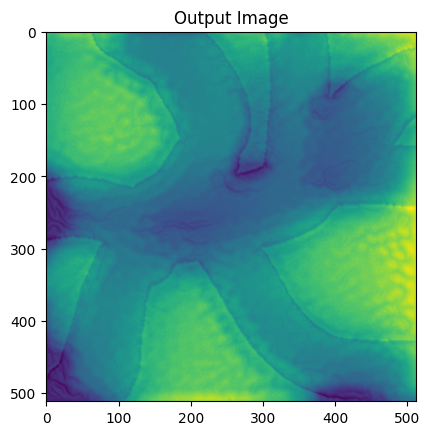

In [21]:
plt.figure()
imshow(output, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()

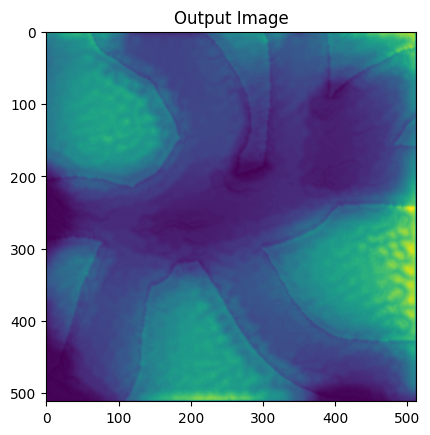

In [39]:
# Scale the "unpassable" part of the output (white mask)
# Here, the input image itself is a mask because "passable" regions are 0, "unpassable" are 1

SCALING_FACTOR = 0.5

input_img = input_img.mean(dim=1, keepdim=True)  # forcibly turn to b&w

BLUR_SIZE = 5
sigma = 1.0

r0 = output * (torch.round(output*1000)/1000) * SCALING_FACTOR

result = gaussian_blur(r0, BLUR_SIZE, sigma)  # smoothen

plt.figure()
imshow(result, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()

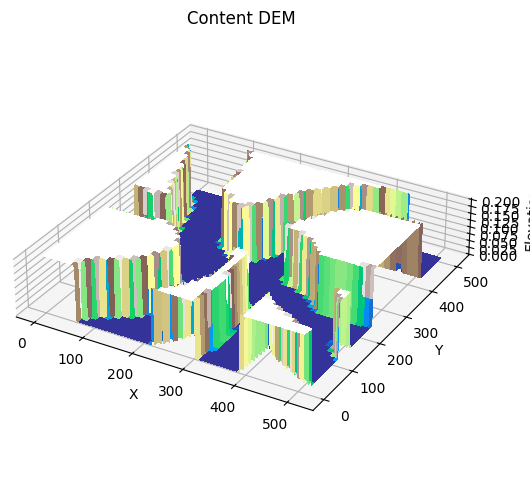

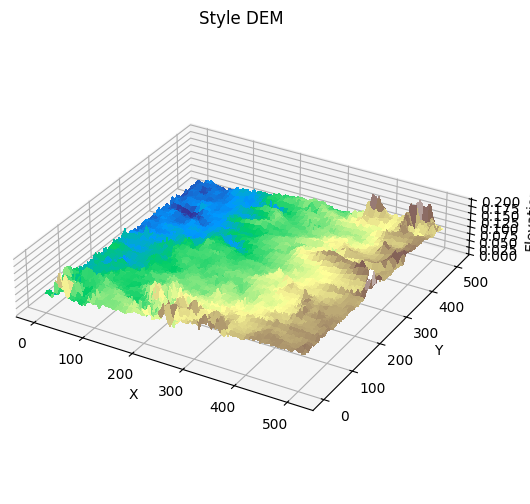

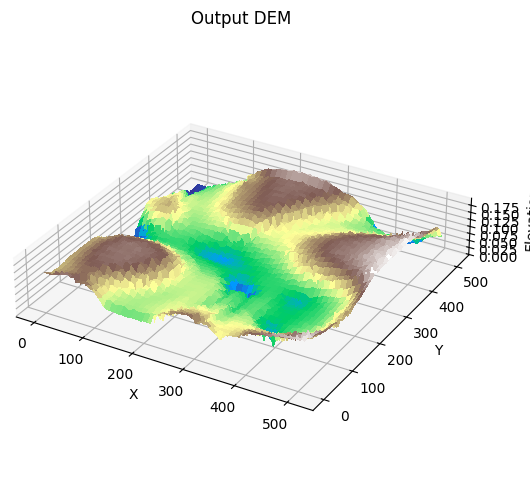

In [40]:
def tensor_to_array(img):
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().clone().squeeze(0)
        if img.shape[0] == 3:  # RGB
            img = img.mean(0)  # convert to grayscale
        else:
            img = img.squeeze(0)
        return img.numpy()
    return img

def plot_surface(img, title="DEM", zscale=1.0):
    arr = tensor_to_array(img)
    x = np.arange(arr.shape[1])
    y = np.arange(arr.shape[0])
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")

    # Scale elevations
    Z = arr * zscale

    # Surface plot
    ax.plot_surface(X, Y, Z, cmap="terrain", linewidth=0, antialiased=False)

    # Labels
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Elevation")

    # Adjust aspect ratio so Z is visually altered too
    ax.set_box_aspect((1, 1, zscale))  # (X, Y, Z) scaling ratio

    plt.show()


# Plot DEMs
plot_surface(content_img, "Content DEM", zscale=0.2)
plot_surface(style_imgs[0], "Style DEM", zscale=0.2)
plot_surface(output, "Output DEM", zscale=0.2)

In [24]:
# Convert tensor to PIL and save
unloader = transforms.ToPILImage()
image = output.cpu().clone().squeeze(0)  # remove batch dim
image = unloader(image)
save_path = "/content/drive/MyDrive/Images/output.png"
image.save(save_path)
print(f"Saved result to {save_path}")

Saved result to /content/drive/MyDrive/Images/output.png
